# The first part of the notebook is a simple notebook to train a Support Vector Machine to discriminate between two types of collisional events. 

It accompanies Chapter 4 of the book.

Data for this exercise were kindly provided by [Sascha Caron](https://www.nikhef.nl/~scaron/).

Copyright: Viviana Acquaviva (2023)

License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

This notebook is modified by Gang Xu for the Scientific Machine Learning course PSI 2026.
# The second part of the notebook use Principle Component Analysis for the same problem.

With the lines performing PCA taken from code by Lauren Hayward, Juan Carrasquilla, and Mohamed Hibat Allah taken from Laurens van der Maaten's implementation of t-SNE in Python.

## SVM witout PCA

### Import libraries<span style="color: blue;"> (no need to change)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # New algorithm!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # New! This will be used to explore different hyperparameter choices.

### Make the display of the dictionary better<span style="color: blue;"> (no need to change)

In [2]:
pd.set_option('display.max_columns', 500) # not display ...
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100) # truncate string at 100 characters
rc('text', usetex=False) # not use latex 

### Read in features and labels and take a look at them<span style="color: blue;"> (no need to change)

In [3]:
features_raw = pd.read_csv('ParticleID_features.csv', index_col='ID')##load features in a dictionary
y_raw = np.genfromtxt('ParticleID_labels.txt', dtype = str)## load labels
print('The features are of the shape:',features_raw.shape)
print('The original labels are:',y_raw)### This shows the original labels are categorical not numerical
features_raw.head()## This part show what our current features look like for a few examples


The features are of the shape: (5000, 77)
The original labels are: ['ttbar' 'ttbar' 'ttbar' ... 'ttbar' '4top' 'ttbar']


,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52,Type_14,P53,P54,P55,P56,Type_15,P57,P58,P59,P60
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.19933,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.2,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.65386,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.3,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.68461,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.8,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.87132,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.1,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.87641,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### We need to turn categorical (string-type) labels into an array, e.g. 0/1.<span style="color: blue;"> (no need to change)

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #turns categorical into 1 ... N
y = le.fit_transform(y_raw)# find unique values and turn into numbers and replace the array with the numbers.
target = np.abs(y - 1)### Our transformer used 1 for the first instance, but we actually wanted 4top to be the positive label, so we'll flip the labels:
print('The numerical labels are',target)

The numerical labels are [0 0 0 ... 0 1 0]


### Let's take a look at these features, using the "describe" property.<span style="color: blue;"> (no need to change)

In [5]:
features_raw.describe() #Note that this automatically excludes non-numerical type columns

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52,P53,P54,P55,P56,P57,P58,P59,P60
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000,14.000000,14.000000,14.000000,14.000000,3.000000,3.000000,3.000000,3.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260,180401.885714,27076.621429,-0.276634,0.595697,205102.000000,24610.900000,-1.333743,1.518666
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400,262972.929941,3332.496623,2.181392,1.760349,230084.978534,1916.495834,2.661912,1.672151
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730,25937.400000,23170.800000,-4.072000,-2.709890,58941.000000,23025.500000,-3.709270,-0.201051
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.000000,-1.226980,-1.513330,4.410735e+04,26589.250000,-1.223240,-1.422415,4.092160e+04,25298.300000,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900,34043.200000,25170.050000,-1.686009,-0.363179,72493.000000,23546.000000,-2.772230,0.708599
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057429,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279,9.206885

### Important:

Looking at the "count" row, we can see that the whole data set has 5,000 rows, but some columns are present only for a fraction of them. This is because of the variable number of products in each collision.

#### Option 1: Only consider first 16 columns (first four products) so we have limited imputing/manipulation problems.


We have a trade-off between keeping more features, but having a more severe missing data/imputing problem, or keeping fewer features, but dealing with a simpler imputing problem. We are choosing the latter.

##### keeping fewer features <span style="color: blue;"> (no need to change)

In [6]:
col_16 = ['MET', 'METphi'] + [f'P{i}' for i in range(1, 17)] 
# Here we take MET METphi and four momentum of first four outputs 
#note that we dropped labels like j or b
features_16 = features_raw[col_16]

features_16.describe()


,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057429,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


##### Fill the NAN with 0's <span style="color: blue;"> (no need to change)

There are still some feature columns with different length! This means there might be NaN values. Let's replace them with 0 for the moment. 

In [7]:
features_16 = features_16.fillna(0) #Fill with 0 everywhere there is a NaN

Note: this is the simplest but worst possible choice - imputing a constant value skews the model :D One step up would be to input the mean or median for each column. However, because only a limited number of instances have missing data, the choice of imputing strategy doesn't matter too much.

##### Let's see what "describe" says now.<span style="color: blue;"> (no need to change)

In [8]:
features_16.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Yay - we now have consistent sizes, so we can use these as feature arrays, BUT be mindful of possible negative impacts of our imputing strategies.

### A quick exploration of labels and benchmarking. 

Write one line code to check if dataset is balanced or not

In [10]:
 #write your one line code here Hint: the numerical labels are stored in target

#Counting number of positive entries

NumberPositiveEntries = sum(target)
print(NumberPositiveEntries)

811


In [ ]:
#811 positive entries out of 5000: mostly negative (unbalanced aet?)

#### Let's start with a linear model; model = SVC() <span style="color: blue;"> (no need to change)

Define a cross-validation strategy; establish the simplest basic model. Is it a good model?

In [12]:
bmodel = LinearSVC(dual = False, C=1000) #Prefer dual=False when n_samples > n_features. If not, will not converge!!
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101) # stratified, preserve label random_state: easy to reproduce the splitting
basic_16 = cross_validate(bmodel, features_16, target, cv = cv, scoring = 'accuracy', return_train_score=True)# only use 4 products 
print(basic_16)
np.round(basic_16['test_score'].mean(),3).item(), np.round(basic_16['test_score'].std(), 3).item()### average test_score and standard deviation

{'fit_time': array([0.03023481, 0.00708032, 0.00640297, 0.00599098, 0.00803304]), 'score_time': array([0.00413585, 0.00068879, 0.00109315, 0.0006361 , 0.00174999]), 'test_score': array([0.841, 0.825, 0.829, 0.83 , 0.833]), 'train_score': array([0.8315 , 0.83275, 0.8315 , 0.83125, 0.832  ])}


(0.832, 0.005)

### Question: is there perhaps something that we should have done before building the SVM model?

#### How about scaling? <span style="color: blue;"> (no need to change)

Implementation notes: Technically, standardizing/normalizing data using the entire learning set introduces leakage between train and test set (the test set "knows" about the mean and standard deviation of the entire data set). Usually this is not a dramatic effect, but the correct procedure is to derive the scaler within each CV fold (i.e. after separating in train and test), only on the train set, and apply the same transformation to the test set. The model then becomes a pipeline.

In [13]:
from sklearn.pipeline import make_pipeline #This allows one to build different steps together
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000)) #Here the features are scaled and fixed the kernel to be linear
# pipeline can do scaling and call the algorithm in one line of code 
bench_16_piped = cross_validate(piped_model, features_16, target, cv = cv, scoring = 'accuracy', return_train_score=True)
print(bench_16_piped)
print(np.round(bench_16_piped['test_score'].mean(),3).item(), np.round(bench_16_piped['test_score'].std(), 3).item())# test score average and std
np.round(bench_16_piped['train_score'].mean(),3).item(), np.round(bench_16_piped['train_score'].std(), 3).item()#train score average and std

{'fit_time': array([0.02662396, 0.00504184, 0.00600505, 0.00506234, 0.00501084]), 'score_time': array([0.00310183, 0.00080991, 0.00124383, 0.00089693, 0.00095797]), 'test_score': array([0.894, 0.889, 0.89 , 0.892, 0.899]), 'train_score': array([0.89575, 0.895  , 0.895  , 0.89825, 0.89275])}
0.893 0.004


(0.895, 0.002)

### Define a function to plot learning curves  <span style="color: blue;"> (no need to change)

In [14]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)
 
    plt.ylabel("Accuracy score",fontsize = 14)
    
    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

#### Plot learning curves  <span style="color: blue;"> (no need to change)

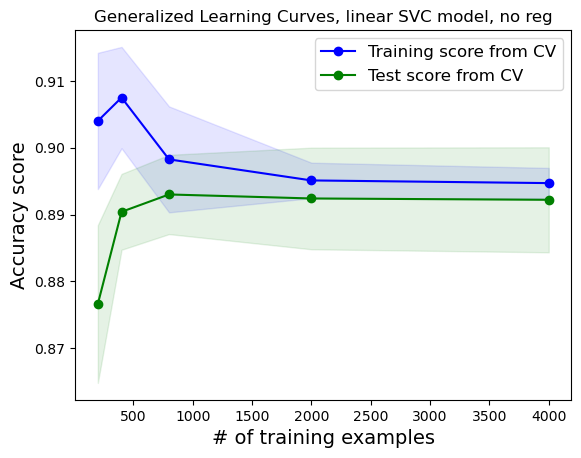

In [15]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg', features_16, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = KFold(n_splits=5, shuffle=True));

### Parameter optimization 

When we optimize parameters with a grid search, we choose the parameters that give the best test scores. This is different from what would happen with new data - to do this fairly, at no point of the training procedure we are allowed to look at the test labels. Therefore, we would need to do <b> nested cross validation </b> to avoid leakage between the parameter optimization and the cross validation procedure and properly evaluate the generalization error.

#### Run new piped_model that we can change the kernel <span style="color: blue;"> (no need to change)

In [16]:
piped_model = make_pipeline(StandardScaler(), SVC()) #now using the general SVC so I can change the kernel

piped_model.get_params() #this shows how we can access parameters both for the scaler and the classifier
#gamma in rbf kernel: large gamma tends to overfit (with wiggly boundary) and small gamma tends to underfit
# check out this to visualize how gamma affects decision boundary https://www.geeksforgeeks.org/machine-learning/gamma-parameter-in-svm/
# large C wants to classify all the data by penalizing the data point not allowed by hard margin, tends to overfit.
# small C tends to underfit
# tolerance controls when to stop training large less accuracte, small slower training 
#max_iter=-1 means train until converge
#svc_degree only applies to poly kernel

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': False,
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

#### We can define a dictionary of parameter values to run the optimization. 

Once you run this cell, the "model" object will have attributes "best_score_", "best_params_" and "best_estimator_", which give us access to the optimal estimator (printed out), as well as "cv_results_" that can be used to visualize the performance of all models.

In [17]:
#optimizing SVC: THIS IS NOT YET NESTED CV
 #student modify the following block for a different set of gamma and C
parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':['scale'], 'svc__C':[1], \
              'svc__degree': [2, 4]}# gamma has a default value 'scale' also available to choose 

model = GridSearchCV(piped_model, parameters, scoring='accuracy', cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 1, return_train_score=True) #verbose: how complicated output is

model.fit(features_16,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.3s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.2s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.2s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.2s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.2s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=rbf; total time=   0.2s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=rbf; total time=   0.2s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=rbf; total time=   0.2s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=rbf; total time=   0.2s
[CV] END svc__C=1, svc__degree=2, svc__gamma=scale, svc__kernel=rbf; total time=   0.2s
[CV] END svc__C=1, svc__degree=4, svc__gamma=scale, svc

#### It is better if we can visualize this in a table that ranks them   <span style="color: blue;"> (no need to change)

Next, we visualize the models in a data frame, and rank them according to their test scores.
I like to look at the mean and std of the test scores, the mean of the train scores (so I can evaluate if they differ and the significance of the result), and also fitting time (we may pick a faster model instead of the best model if the scores are comparable)!

In [18]:
scores_16 = pd.DataFrame(model.cv_results_)
scores_16[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
1,"{'svc__C': 1, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8938,0.008841,0.92210,0.153074
3,"{'svc__C': 1, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8938,0.008841,0.92210,0.154092
0,"{'svc__C': 1, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8756,0.005004,0.88225,0.193885
2,"{'svc__C': 1, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8738,0.004261,0.91595,0.211632


#### Now let us do grid search over gamma and C 

In [24]:
#optimizing SVC: THIS IS NOT YET NESTED CV

parameters = {'svc__kernel':['rbf'], \
               'svc__gamma':[0.001,0.01,0.1,'scale',1], 'svc__C':[0.01,0.1,1,10,100]}

#parameters = {'svc__kernel':['rbf'], \
#              'svc__gamma':[0.01,0.015,0.1,'scale',10], 'svc__C':[0.01,0.01,1,100,100]}# gamma has a default value 'scale' also available to choose
# student play with gamma and C for the search
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 1, return_train_score=True) #verbose: how complicated output is

model.fit(features_16,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END .....svc__C=0.01, svc__gamma=0.001, svc__kernel=rbf; total time=   0.3s
[CV] END .....svc__C=0.01, svc__gamma=0.001, svc__kernel=rbf; total time=   0.2s
[CV] END .....svc__C=0.01, svc__gamma=0.001, svc__kernel=rbf; total time=   0.2s
[CV] END .....svc__C=0.01, svc__gamma=0.001, svc__kernel=rbf; total time=   0.2s
[CV] END .....svc__C=0.01, svc__gamma=0.001, svc__kernel=rbf; total time=   0.2s
[CV] END ......svc__C=0.01, svc__gamma=0.01, svc__kernel=rbf; total time=   0.2s
[CV] END ......svc__C=0.01, svc__gamma=0.01, svc__kernel=rbf; total time=   0.3s
[CV] END ......svc__C=0.01, svc__gamma=0.01, svc__kernel=rbf; total time=   0.3s
[CV] END ......svc__C=0.01, svc__gamma=0.01, svc__kernel=rbf; total time=   0.3s
[CV] END ......svc__C=0.01, svc__gamma=0.01, svc__kernel=rbf; total time=   0.3s
[CV] END .......svc__C=0.01, svc__gamma=0.1, svc__kernel=rbf; total time=   0.3s
[CV] END .......svc__C=0.01, svc__gamma=0.1, sv

#### Next, we visualize the models in a data frame, and rank them according to their test scores.

I like to look at the mean and std of the test scores, the mean of the train scores (so I can evaluate if they differ and the significance of the result), and also fitting time (we may pick a faster model instead of the best model if the scores are comparable)!

In [22]:
scores_16 = pd.DataFrame(model.cv_results_)

scores_16.columns
scores_16[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
11,"{'svc__C': 1, 'svc__gamma': 0.015, 'svc__kernel': 'rbf'}",0.8948,0.005913,0.90420,0.135139
12,"{'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8936,0.008114,0.93905,0.189109
13,"{'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8932,0.007222,0.92135,0.155050
20,"{'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8918,0.010980,0.93275,0.249450
15,"{'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8918,0.010980,0.93275,0.246942
10,"{'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8918,0.005671,0.90025,0.133252
21,"{'svc__C': 100, 'svc__gamma': 0.015, 'svc__kernel': 'rbf'}",0.8854,0.010855,0.94680,0.271525
16,"{'svc__C': 100, 'svc__gamma': 0.015, 'svc__kernel': 'rbf'}",0.8854,0.010855,0.94680,0.285932
22,"{'svc__C': 100, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8674,0.010837,1.00000,0.253461
17,"{'svc__C': 100, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8674,0.010837,1.00000,0.241145


### Redo with all features included

#### Clean (with only numeric columns NAN replaced by 0) features<span style="color: blue;"> (no need to change)

In [23]:
col_all = ['MET', 'METphi'] + [f'P{i}' for i in range(1, 61)] 
# Here we take MET METphi and four momentum of first four outputs 
#note that we dropped labels like j or b
features_all = features_raw[col_all]
features_all = features_all.fillna(0)
features_all.describe()


,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52,P53,P54,P55,P56,P57,P58,P59,P60
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.00000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704,1.425005e+05,39057.934020,0.012140,-0.025062,9.793672e+04,25289.301200,-0.013177,0.008339,6.153702e+04,15546.87412,0.000842,0.002545,3.751102e+04,9547.391800,0.017161,-0.008517,2.328155e+04,5852.308460,0.008989,-0.006688,1.391450e+04,3509.748580,0.010479,0.002144,8.149253e+03,1992.667980,0.001538,0.001379,4.142869e+03,885.871980,0.005257,-0.000028,1.631392e+03,404.893260,-0.000010,0.002456,505.125280,75.814540,-0.000775,0.001668,123.061200,14.766540,-0.000800,0.000911
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070,2.413624e+05,30530.754194,1.560681,1.596288,1.992033e+05,28137.109217,1.368922,1.372297,1.602738e+05,23759.72563,1.115606,1.088924,1.231563e+05,21456.079083,0.894672,0.875015,1.045843e+05,18232.343896,0.703574,0.682745,7.831865e+04,14461.385282,0.557054,0.542522,6.327000e+04,10809.108843,0.429882,0.399832,4.396717e+04,6375.089165,0.319008,0.309426,2.550795e+04,4672.794272,0.203668,0.201709,16453.781564,1440.952258,0.112197,0.095129,6812.479365,603.938672,0.062464,0.050019
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130,0.000000e+00,0.000000,-4.778980,-3.139040,0.000000e+00,0.000000,-4.930230,-3.140380,0.000000e+00,0.00000,-4.758150,-3.135630,0.000000e+00,0.000000,-4.606330,-3.132610,0.000000e+00,0.000000,-4.814380,-3.136380,0.000000e+00,0.000000,-4.803880,-3.135910,0.000000e+00,0.000000,-4.400470,-3.130690,0.000000e+00,0.000000,-4.447660,-3.139820,0.000000e+00,0.000000,-4.448760,-2.990730,0.000000,0.000000,-4.072000,-2.709890,0.000000,0.000000,-3.709270,-0.201051
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080,3.199550e+04,24749.850000,-0.841946,-1.203655,0.000000e+00,0.000000,-0.345776,-0.416750,0.000000e+00,0.00000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000,6.994990e+04,35691.850000,0.000000,0.000000,3.679670e+04,25597.300000,0.000000,0.000000,0.000000e+00,0.00000,0.000000,0.00

#### Write your own code to rerun our best linear model and non-linear for all the features (we should have rerun the optimization, but in lieu of time...)

In [36]:
### write your code to run previous linear model
piped_modellin = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000))
bench_16_pipedlin = cross_validate(piped_modellin, features_all, target, cv = cv, scoring = 'recall', return_train_score=True)
print(bench_16_pipedlin)
print(np.round(bench_16_pipedlin['test_score'].mean(),3).item(), np.round(bench_16_pipedlin['test_score'].std(), 3).item())# test score average and std
np.round(bench_16_pipedlin['train_score'].mean(),3).item(), np.round(bench_16_pipedlin['train_score'].std(), 3).item()#train score average and std

{'fit_time': array([0.04607201, 0.14624   , 0.02051401, 0.02462006, 0.01949692]), 'score_time': array([0.00455689, 0.00232816, 0.00205994, 0.00181603, 0.00172091]), 'test_score': array([0.77777778, 0.68518519, 0.79012346, 0.71604938, 0.73006135]), 'train_score': array([0.7550077 , 0.77657935, 0.74422188, 0.77349769, 0.77160494])}
0.74 0.039


(0.764, 0.012)

In [37]:
####### write your code to run the previous best nonlinear model
bench_16_piped = cross_validate(piped_model, features_all, target, cv = cv, scoring = 'recall', return_train_score=True)
print(bench_16_piped)
print(np.round(bench_16_piped['test_score'].mean(),3).item(), np.round(bench_16_piped['test_score'].std(), 3).item())# test score average and std
np.round(bench_16_piped['train_score'].mean(),3).item(), np.round(bench_16_piped['train_score'].std(), 3).item()#train score average and std

{'fit_time': array([0.26491213, 0.217659  , 0.22325921, 0.21560001, 0.22209311]), 'score_time': array([0.09298182, 0.12167287, 0.09412384, 0.08874989, 0.09281468]), 'test_score': array([0.78395062, 0.70987654, 0.7962963 , 0.77777778, 0.7607362 ]), 'train_score': array([0.83359014, 0.8459168 , 0.82896764, 0.8459168 , 0.85493827])}
0.766 0.03


(0.842, 0.009)

### Evaluation 

#### Recall

##### this is for our basic model without scaling with laughable results<span style="color: blue;"> (no need to change)

In [26]:
recall_16 = cross_validate(bmodel, features_16, target, cv = cv, scoring = 'recall', return_train_score=True)
np.round(recall_16['test_score'].mean(),3).item(), np.round(recall_16['test_score'].std(), 3).item()

(0.032, 0.011)

##### this is for our piped_model with scaled features<span style="color: blue;"> (no need to change)

In [27]:
recall_16_piped = cross_validate(piped_model, features_16, target, cv = cv, scoring = 'recall', return_train_score=True)
print(np.round(recall_16_piped['test_score'].mean(),3).item(), np.round(recall_16_piped['test_score'].std(), 3).item())
np.round(recall_16_piped['train_score'].mean(),3).item(), np.round(recall_16_piped['train_score'].std(), 3).item()

0.547 0.03


(0.637, 0.007)

##### Confusion Matrix<span style="color: blue;"> (no need to change)

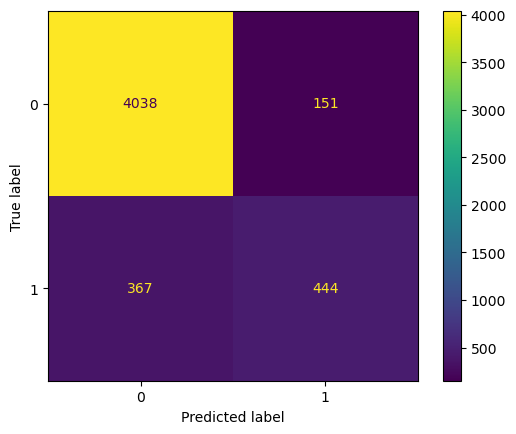

In [28]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = cross_val_predict(piped_model, features_16, target, cv=cv)

ConfusionMatrixDisplay.from_predictions(target, y_pred)


### Feature engineering: Next step: define some new variables. 

#### data cleaning: fill NAN and empty string <span style="color: blue;"> (no need to change)

In [29]:
features = features_raw.fillna(0) #takes care of nan
features = features.replace('', 0) #takes care of empty string values
features.head()

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52,Type_14,P53,P54,P55,P56,Type_15,P57,P58,P59,P60
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.19933,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
1,57594.2,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.65386,-3.129630,0,0.0,0.0,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
2,82313.3,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.68461,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
3,30610.8,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.87132,0.817631,j,28235.4,25887.9,-0.411528,2.024290,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
4,45153.1,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.87641,0.865381,j,746585.0,26219.3,4.041820,-0.874169,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


#### Let's start by looking at what kind of particles we have as a product of the collision.<span style="color: blue;"> (no need to change)

In [30]:
np.unique(np.array([features['Type_'+str(i)].values for i in range(1,16)]).astype('str'))

array(['0', 'b', 'e+', 'e-', 'g', 'j', 'm+', 'm-'], dtype='<U2')

#### Here are the proposed new features .
    
    1. The total number of particles produced
    2. The total number of b jets
    3. The total number of jets
    4. The total number of leptons (electrons, positron, mu+, mu-)

#### count all types of outputs <span style="color: blue;"> (no need to change)

In [31]:
#count number of non-zero types 
ntot = np.array([15-np.sum(np.array([features['Type_'+str(i)].values[j] == 0 for i in range(1,16)]))  for j in range(features.shape[0])])
#count b jets
nbtot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'b' for i in range(1,16)])) for j in range(features.shape[0])])
### count all sorts of output 
njtot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'j' for i in range(1,16)])) for j in range(features.shape[0])])
ngtot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'g' for i in range(1,16)])) for j in range(features.shape[0])])
n_el_tot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'e-' for i in range(1,16)])) for j in range(features.shape[0])])
n_pos_tot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'e+' for i in range(1,16)])) for j in range(features.shape[0])])
n_muneg_tot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'm-' for i in range(1,16)])) for j in range(features.shape[0])])
n_mupos_tot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'm+' for i in range(1,16)])) for j in range(features.shape[0])])
#### add up to find total lepton number
n_lepton_tot = n_el_tot+n_pos_tot+n_muneg_tot+n_mupos_tot 

#### and we define new features 

In [ ]:
features['Total_b'] = nbtot#define new column in my data frame
features['Total_products'] = ntot#define new column in my data frame
#count number of b jets 
### below define your own features
features['Total_j']=njtot

### Feature engineering 1: impact of ad-hoc variables

#### Include new features in the feature list 

In [46]:
columns = ['MET', 'METphi'] + [f'P{i}' for i in range(1, 17)] + ['Total_b','Total_products']#### modify this

features_16_eng = features[columns]

#### Remember our piped model?<span style="color: blue;"> (no need to change)

In [47]:
from sklearn.pipeline import make_pipeline
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000)) 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101) 

#### Run with new engineered data<span style="color: blue;"> (no need to change)

##### Use accuracy<span style="color: blue;"> (no need to change)

In [48]:
eng_16_piped = cross_validate(piped_model, features_16_eng, target, cv = cv, scoring = 'accuracy', return_train_score=True)
print(eng_16_piped)
print(np.round(eng_16_piped['test_score'].mean(),3).item(), np.round(eng_16_piped['test_score'].std(), 3).item())
np.round(eng_16_piped['train_score'].mean(),3).item(), np.round(eng_16_piped['train_score'].std(), 3).item()

{'fit_time': array([0.02650595, 0.00589514, 0.00568199, 0.005934  , 0.00477314]), 'score_time': array([0.00350118, 0.00127101, 0.00114894, 0.00112891, 0.00074291]), 'test_score': array([0.952, 0.941, 0.963, 0.943, 0.941]), 'train_score': array([0.947  , 0.9515 , 0.94675, 0.949  , 0.9505 ])}
0.948 0.009


(0.949, 0.002)

##### Use recall<span style="color: blue;"> (no need to change)

In [49]:
eng_16_piped = cross_validate(piped_model, features_16_eng, target, cv = cv, scoring = 'recall', return_train_score=True)
print(eng_16_piped)
print(np.round(eng_16_piped['test_score'].mean(),3).item(), np.round(eng_16_piped['test_score'].std(), 3).item())
np.round(eng_16_piped['train_score'].mean(),3).item(), np.round(eng_16_piped['train_score'].std(), 3).item()

{'fit_time': array([0.01517701, 0.00692773, 0.00642419, 0.00539422, 0.00559711]), 'score_time': array([0.00563908, 0.00222802, 0.001791  , 0.00146389, 0.00138783]), 'test_score': array([0.81481481, 0.74691358, 0.83950617, 0.7962963 , 0.77300613]), 'train_score': array([0.8027735 , 0.81664099, 0.79044684, 0.79198767, 0.80555556])}
0.794 0.032


(0.801, 0.01)

##### Take a look at the confusion matrix <span style="color: blue;"> (no need to change)

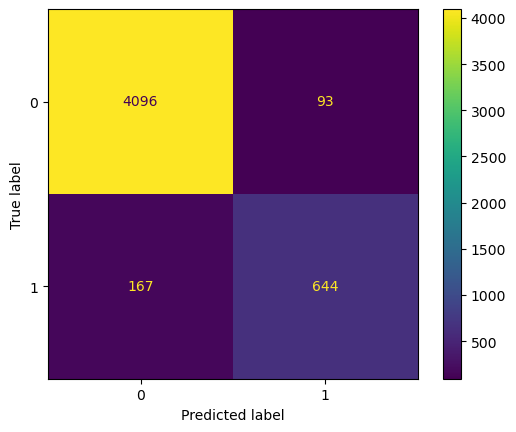

In [50]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_eng = cross_val_predict(piped_model, features_16_eng, target, cv=cv)

ConfusionMatrixDisplay.from_predictions(target, y_pred_eng)

## PCA

### Take all the data but without the engineered data <span style="color: blue;"> (no need to change)

In [51]:
columns = ['MET', 'METphi'] + [f'P{i}' for i in range(1, 61)] 

features_all = features[columns]### remember we already cleaned features there is no NAN there any more

### Scale the data and perform PCA find lambda and y and X' in the tutorial<span style="color: blue;"> (no need to change)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features_all) ### simplified naming system, X is the X in the tutorial
X_c=X-np.mean(X,axis=0) ### braodcasting 
(lamb, P) = np.linalg.eig(np.dot(X_c.T,X_c)/(features_all.shape[0]-1))
 ### Sort according to decreasing order of the eigenvalues: ###
num_components = features_all.shape[1]
indices_sorted = lamb.argsort()[::-1] #The [::-1] is to get the reverse order (largest eigenvalues first)
lamb = lamb[indices_sorted]
P = P[:,indices_sorted]

    ### Get the principal components (columns of the matrix X_prime): ###
X_prime = np.dot(X_c, P[:,0:num_components])


### Explained variance ratio and the cumulative-explained variance plot

In [ ]:
howmany = num_components # you may want to change this after seeing the plot
fig, ax = plt.subplots(1, 2)

###### student code here
ratios = 



ratios =ratios[:howmany]
ax[0].semilogy(np.arange(howmany), ratios, 'o-', label='all features')

cumulative=np.cumsum(ratios)

ax[1].semilogy(np.arange(howmany), cumulative, 'o-', label='all features')
plt.tight_layout()
plt.show


### Plot the first two principle components against each other with color coding<

In [ ]:

### PLOT FIGURE (first two principal components): ###
plt.figure()

sc = plt.scatter(, , c=y, s=40, cmap=plt.cm.coolwarm) # #### student fill in the ploting stuff

cb = plt.colorbar(sc, cmap=plt.cm.coolwarm) #PART B
plt.title('first two component scatter plot')
plt.xlabel(r"$x'_1$")
plt.ylabel(r"$x'_2$")
 

##### Write your code to take the first k components to run SVM and perform confusion matrix study 

In [ ]:
mylist = [1, 2, 5, 10, 20, 50]


### Now we add the engineered features 

In [ ]:
columns = ['MET', 'METphi'] + [f'P{i}' for i in range(1, 61)] + [
     ### student modify here
]

features_all_eng = features[columns]

#### Write code here to redo all the analysis for PCA+SVM before

In [ ]:
### Student write code here